In [1]:
import pandas as pd 
import os 
import re
import numpy as np 
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.display.max_columns = 100
pd.options.display.max_rows = 60


In [408]:
np.setdiff1d(needed_files, os.listdir(data_dir))

array(['admissionDrug.csv.gz', 'index.html', 'infusionDrug.csv.gz'],
      dtype='<U32')

In [2]:
demo = False 
# Make sure you are in the directory where you downloaded the data. For me, this folder unzipped is named eicu-collaborative-research-database-demo-2.0.1
if demo:
    data_dir = './eicu-collaborative-research-database-demo-2.0.1/'
else:
    data_dir = './physionet.org/files/eicu-crd/2.0/'

assert os.path.exists(data_dir), f"Data directory {data_dir} does not exist. Please check that you've downloaded the data to the correct path name." 
needed_files = ['diagnosis.csv.gz', 'index.html', 'vitalAperiodic.csv.gz', 'admissionDx.csv.gz', 'respiratoryCare.csv.gz', 'nurseAssessment.csv.gz', 'hospital.csv.gz', 'vitalPeriodic.csv.gz', 'carePlanGeneral.csv.gz', 'patient.csv.gz', 'carePlanGoal.csv.gz', 'treatment.csv.gz', 'apacheApsVar.csv.gz', 'carePlanEOL.csv.gz', 'infusionDrug.csv.gz', 'carePlanCareProvider.csv.gz', 'microLab.csv.gz', 'nurseCare.csv.gz', 'physicalExam.csv.gz', 'respiratoryCharting.csv.gz', 'note.csv.gz', 
                'admissionDrug.csv.gz', 'lab.csv.gz', 'LICENSE.txt', 'apachePredVar.csv.gz', 
                'customLab.csv.gz', 'apachePatientResult.csv.gz', 'carePlanInfectiousDisease.csv.gz', 
                'allergy.csv.gz', 'nurseCharting.csv.gz', 'pastHistory.csv.gz', 'medication.csv.gz', 'intakeOutput.csv.gz']
assert np.setdiff1d(needed_files, os.listdir(data_dir)).shape[0] == 0 # Folder should contain all the needed files. If not, check that you've downloaded the data correctly.


### Patient table
* `patienthealthsystemstayid`: denotes a unique hospital visit 
* An admission means admission to the ICU, which can happen multiple times in a patient's hospital visit. 
* `patientUnitStayID`: unique ICU visit, w/in a hospital visit 
* `apacheAdmissionDx`: string describing why they were admitted to ICU
* `hospitaladmitoffset`: number of minutes from unit admit time that the patient was admitted to the hospital
* `unittype` and `unitAdmitSource`: Further describes ICU unit type (finite set ie. Burn-trauma ICU)
* `unitDischargeStatus`: patient's condition upon leaving ICU (i.e., death)
* `apacheadmissiondx` : the summarized note after ICU admission, including diagnoses made during the visit ; non-coded so might drop 


Irrelevant, can drop:
* `wardid`, `hospitaladmitsource`

In [3]:
patient = pd.read_csv(f'{data_dir}/patient.csv.gz')
patient

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitoffset,hospitaladmitsource,hospitaldischargeyear,hospitaldischargetime24,hospitaldischargeoffset,hospitaldischargelocation,hospitaldischargestatus,unittype,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141168,128919,Female,70,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",152.4,15:54:00,0,Direct Admit,2015,03:50:00,3596,Death,Expired,Med-Surg ICU,15:54:00,Direct Admit,1,admit,84.3,85.8,03:50:00,3596,Death,Expired,002-34851
1,141178,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,-14,Emergency Department,2015,19:20:00,2050,Home,Alive,Med-Surg ICU,09:10:00,Emergency Department,1,admit,54.4,54.4,09:18:00,8,Step-Down Unit (SDU),Alive,002-33870
2,141179,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,-22,Emergency Department,2015,19:20:00,2042,Home,Alive,Med-Surg ICU,09:18:00,ICU to SDU,2,stepdown/other,NaN,60.4,19:20:00,2042,Home,Alive,002-33870
3,141194,128941,Male,68,Caucasian,73,92,"Sepsis, renal/UTI (including bladder)",180.3,18:18:40,-780,Floor,2015,23:30:00,12492,Home,Alive,CTICU,07:18:00,Floor,1,admit,73.9,76.7,15:31:00,4813,Floor,Alive,002-5276
4,141196,128943,Male,71,Caucasian,67,109,NaN,162.6,20:21:00,-99,Emergency Department,2015,17:00:00,5460,Home,Alive,Med-Surg ICU,22:00:00,ICU to SDU,2,stepdown/other,NaN,63.2,22:23:00,1463,Floor,Alive,002-37665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200854,3353235,2743084,Male,50,Caucasian,458,1109,"CHF, congestive heart failure",175.3,04:55:00,-34,Emergency Department,2014,21:00:00,3811,Home,Alive,Cardiac ICU,05:29:00,Emergency Department,1,admit,90.0,99.2,23:18:00,1069,Telemetry,Alive,035-16382
200855,3353237,2743086,Female,79,Caucasian,458,1106,"Embolus, pulmonary",162.6,01:45:00,-14,Direct Admit,2014,19:04:00,9665,Home,Alive,MICU,01:59:00,Direct Admit,1,admit,78.4,81.4,23:08:00,1269,Step-Down Unit (SDU),Alive,035-751
200856,3353251,2743099,Male,73,African American,458,1104,Cardiac arrest (with or without respiratory ar...,177.8,12:51:00,-206,Emergency Department,2014,22:35:00,19098,Home,Alive,Cardiac ICU,16:17:00,Emergency Department,1,admit,102.0,96.2,23:16:00,16259,Telemetry,Alive,035-5166
200857,3353254,2743102,Male,81,Caucasian,459,1108,"Bleeding, lower GI",185.4,07:43:00,-271,Emergency Department,2015,18:38:00,6144,Home,Alive,Med-Surg ICU,12:14:00,Emergency Department,1,admit,83.9,92.9,19:25:00,431,Step-Down Unit (SDU),Alive,035-19511


In [4]:
N = patient.uniquepid.nunique()
hours_mortality = 48 
hours_for_data = 24

patient = patient[patient.hospitaldischargeoffset > (hours_for_data*60)]
print(f"Removed {N-patient.uniquepid.nunique()} patients who were discharged before {hours_mortality/2} hours")

Removed 11106 patients who were discharged before 24.0 hours


In [5]:
N = patient.uniquepid.nunique()
invalid = (patient.unitdischargeoffset - patient.hospitaladmitoffset) > hours_mortality*60
print(f"Removing {invalid.sum()} ICU visits that end after {hours_mortality} hours = Removing {N-patient.uniquepid.nunique()} patients who have no remaining data (usually 0)")
patient = patient[~invalid]
patient[f'mortality_at{hours_mortality}h'] = (patient.unitdischargestatus == 'Expired').astype(int)
patient[f'mortality_at{hours_mortality}h'] = patient.groupby('patienthealthsystemstayid')[f'mortality_at{hours_mortality}h'].transform('max')
print(f"Mortality rate of patients between {hours_for_data}-{hours_mortality} hours: ", patient[f'mortality_at{hours_mortality}h'].mean())
patient

Removing 109188 ICU visits that end after 48 hours = Removing 0 patients who have no remaining data (usually 0)
Mortality rate of patients between 24-48 hours:  0.016759852535063735


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitoffset,hospitaladmitsource,hospitaldischargeyear,hospitaldischargetime24,hospitaldischargeoffset,hospitaldischargelocation,hospitaldischargestatus,unittype,unitadmittime24,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid,mortality_at48h
1,141178,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,-14,Emergency Department,2015,19:20:00,2050,Home,Alive,Med-Surg ICU,09:10:00,Emergency Department,1,admit,54.4,54.4,09:18:00,8,Step-Down Unit (SDU),Alive,002-33870,0
2,141179,128927,Female,52,Caucasian,60,83,NaN,162.6,08:56:00,-22,Emergency Department,2015,19:20:00,2042,Home,Alive,Med-Surg ICU,09:18:00,ICU to SDU,2,stepdown/other,NaN,60.4,19:20:00,2042,Home,Alive,002-33870,0
4,141196,128943,Male,71,Caucasian,67,109,NaN,162.6,20:21:00,-99,Emergency Department,2015,17:00:00,5460,Home,Alive,Med-Surg ICU,22:00:00,ICU to SDU,2,stepdown/other,NaN,63.2,22:23:00,1463,Floor,Alive,002-37665,0
5,141197,128943,Male,71,Caucasian,67,109,"Sepsis, pulmonary",162.6,20:21:00,-25,Emergency Department,2015,17:00:00,5534,Home,Alive,Med-Surg ICU,20:46:00,Emergency Department,1,admit,102.1,102.1,22:00:00,74,Step-Down Unit (SDU),Alive,002-37665,0
8,141227,128968,Male,82,Caucasian,60,83,"Sepsis, pulmonary",185.4,19:19:00,-1004,Floor,2015,16:35:00,1712,Other Hospital,Alive,Med-Surg ICU,12:03:00,Floor,1,admit,82.2,82.2,15:35:00,1652,Other Hospital,Alive,002-21459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200842,3353184,2743043,Female,83,Caucasian,458,1109,Cardiomyopathy,163.0,17:53:00,-305,Emergency Department,2015,16:18:00,5360,Home,Alive,Cardiac ICU,22:58:00,Emergency Department,1,admit,46.7,NaN,20:10:00,1272,Telemetry,Alive,035-1687,0
200854,3353235,2743084,Male,50,Caucasian,458,1109,"CHF, congestive heart failure",175.3,04:55:00,-34,Emergency Department,2014,21:00:00,3811,Home,Alive,Cardiac ICU,05:29:00,Emergency Department,1,admit,90.0,99.2,23:18:00,1069,Telemetry,Alive,035-16382,0
200855,3353237,2743086,Female,79,Caucasian,458,1106,"Embolus, pulmonary",162.6,01:45:00,-14,Direct Admit,2014,19:04:00,9665,Home,Alive,MICU,01:59:00,Direct Admit,1,admit,78.4,81.4,23:08:00,1269,Step-Down Unit (SDU),Alive,035-751,0
200857,3353254,2743102,Male,81,Caucasian,459,1108,"Bleeding, lower GI",185.4,07:43:00,-271,Emergency Department,2015,18:38:00,6144,Home,Alive,Med-Surg ICU,12:14:00,Emergency Department,1,admit,83.9,92.9,19:25:00,431,Step-Down Unit (SDU),Alive,035-19511,0


In [6]:
patient.drop(columns=['wardid', 'dischargeweight', 'hospitaladmittime24', 'hospitaladmitsource', 'apacheadmissiondx',
                      'unittype', 'unitadmittime24', 'unitadmitsource','unitdischargetime24', 'hospitaldischargetime24', 
                      'unitdischargeoffset', 
                      'hospitaldischargeoffset', 'hospitaldischargelocation', 'unitstaytype', 'unitdischargelocation', ], inplace=True)
patient

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargestatus,unitvisitnumber,admissionweight,unitdischargestatus,uniquepid,mortality_at48h
1,141178,128927,Female,52,Caucasian,60,162.6,-14,2015,Alive,1,54.4,Alive,002-33870,0
2,141179,128927,Female,52,Caucasian,60,162.6,-22,2015,Alive,2,NaN,Alive,002-33870,0
4,141196,128943,Male,71,Caucasian,67,162.6,-99,2015,Alive,2,NaN,Alive,002-37665,0
5,141197,128943,Male,71,Caucasian,67,162.6,-25,2015,Alive,1,102.1,Alive,002-37665,0
8,141227,128968,Male,82,Caucasian,60,185.4,-1004,2015,Alive,1,82.2,Alive,002-21459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200842,3353184,2743043,Female,83,Caucasian,458,163.0,-305,2015,Alive,1,46.7,Alive,035-1687,0
200854,3353235,2743084,Male,50,Caucasian,458,175.3,-34,2014,Alive,1,90.0,Alive,035-16382,0
200855,3353237,2743086,Female,79,Caucasian,458,162.6,-14,2014,Alive,1,78.4,Alive,035-751,0
200857,3353254,2743102,Male,81,Caucasian,459,185.4,-271,2015,Alive,1,83.9,Alive,035-19511,0


### Hospital table
* `numbedscategory` and `region` will be useful for looking at generalization 

Irrelevant, can drop:
* `teachingstatus`

In [7]:
hospital = pd.read_csv(f'{data_dir}/hospital.csv.gz')
hospital

,hospitalid,numbedscategory,teachingstatus,region
0,56,<100,f,Midwest
1,58,100 - 249,f,Midwest
2,59,<100,f,Midwest
3,60,<100,f,Midwest
4,61,<100,f,Midwest
...,...,...,...,...
203,447,NaN,f,Midwest
204,449,>= 500,t,Midwest
205,452,NaN,f,Midwest
206,458,>= 500,f,South


In [8]:
patient = patient.merge(hospital.drop(columns='teachingstatus').rename(
    columns={c: f"hospital_{c}" for c in hospital.columns if c != 'hospitalid'}), 
               on='hospitalid', how='left')
patient

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargestatus,unitvisitnumber,admissionweight,unitdischargestatus,uniquepid,mortality_at48h,hospital_numbedscategory,hospital_region
0,141178,128927,Female,52,Caucasian,60,162.6,-14,2015,Alive,1,54.4,Alive,002-33870,0,<100,Midwest
1,141179,128927,Female,52,Caucasian,60,162.6,-22,2015,Alive,2,NaN,Alive,002-33870,0,<100,Midwest
2,141196,128943,Male,71,Caucasian,67,162.6,-99,2015,Alive,2,NaN,Alive,002-37665,0,NaN,Midwest
3,141197,128943,Male,71,Caucasian,67,162.6,-25,2015,Alive,1,102.1,Alive,002-37665,0,NaN,Midwest
4,141227,128968,Male,82,Caucasian,60,185.4,-1004,2015,Alive,1,82.2,Alive,002-21459,0,<100,Midwest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73504,3353184,2743043,Female,83,Caucasian,458,163.0,-305,2015,Alive,1,46.7,Alive,035-1687,0,>= 500,South
73505,3353235,2743084,Male,50,Caucasian,458,175.3,-34,2014,Alive,1,90.0,Alive,035-16382,0,>= 500,South
73506,3353237,2743086,Female,79,Caucasian,458,162.6,-14,2014,Alive,1,78.4,Alive,035-751,0,>= 500,South
73507,3353254,2743102,Male,81,Caucasian,459,185.4,-271,2015,Alive,1,83.9,Alive,035-19511,0,100 - 249,South


In [9]:
# Aggregate across ICU visits all within 24 horus of each hospital visit
keep_cols = [
    'gender', 'age', 'ethnicity', 'hospitalid',
    'hospitaldischargeyear', 'mortality_at48h',
    'hospital_numbedscategory', 'hospital_region'
]

# Make sure all the keep_cols are same across all ICU visits 
bad = patient.groupby('patienthealthsystemstayid')[keep_cols].nunique().gt(1)
assert not bad.any().any(), patient.loc[patient['patienthealthsystemstayid'].isin(bad.index[bad.any(axis=1)])]

# Then we aggregate
patient_agg = patient.groupby('patienthealthsystemstayid').agg({
               **{c: 'first' for c in keep_cols}, # doesn't matter what these are bc they are the same 
               'admissionheight': 'mean',
               'admissionweight': 'mean'
           }).reset_index()
patient_agg

,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,hospitaldischargeyear,mortality_at48h,hospital_numbedscategory,hospital_region,admissionheight,admissionweight
0,128927,Female,52,Caucasian,60,2015,0,<100,Midwest,162.6,54.4
1,128943,Male,71,Caucasian,67,2015,0,None,Midwest,162.6,102.1
2,128968,Male,82,Caucasian,60,2015,0,<100,Midwest,185.4,82.2
3,128970,Female,> 89,Caucasian,63,2014,0,100 - 249,Midwest,160.0,89.8
4,128995,Female,43,African American,73,2015,0,>= 500,Midwest,172.7,69.9
...,...,...,...,...,...,...,...,...,...,...,...
66996,2743043,Female,83,Caucasian,458,2015,0,>= 500,South,163.0,46.7
66997,2743084,Male,50,Caucasian,458,2014,0,>= 500,South,175.3,90.0
66998,2743086,Female,79,Caucasian,458,2014,0,>= 500,South,162.6,78.4
66999,2743102,Male,81,Caucasian,459,2015,0,100 - 249,South,185.4,83.9


In [10]:
feature_sets = {} 

### Diagnosis table - features (<= 24 hrs)
* `icd9code` is the most important but needs to be preprocessed into codes 

Irrelevant, can drop:
* `diagnosisstring` 

In [11]:
diagnosis = pd.read_csv(f'{data_dir}/diagnosis.csv.gz')
diagnosis = diagnosis[diagnosis.patientunitstayid.isin(patient.patientunitstayid.unique())]
diagnosis = diagnosis.merge(patient[['patientunitstayid', 'hospitaladmitoffset']], on='patientunitstayid', how='left')
diagnosis['time_from_admit'] = - diagnosis.hospitaladmitoffset + diagnosis.diagnosisoffset # minutes after hosptial admission given diagnosis 

pattern = r"\b[A-TV-Z][0-9]{2}(?:\.[0-9A-Z]{1,4})?\b"    
diagnosis['icd9code_pp'] = diagnosis.icd9code.astype(str).apply(lambda x: re.findall(pattern, x))
diagnosis = diagnosis.explode("icd9code_pp").rename(columns={"icd9code_pp": "icd10"}).drop(columns=[
    'icd9code','diagnosispriority', 'activeupondischarge',  'diagnosisstring','diagnosisid'])

In [12]:
diagnosis_before24h = diagnosis[diagnosis.time_from_admit <= hours_for_data*60] # these can be our features used for prediction
diagnosis_after24h = diagnosis[(diagnosis.time_from_admit > hours_for_data*60)] # may be used as labels for prediction, if desired 
diagnosis_before24h

,patientunitstayid,diagnosisoffset,hospitaladmitoffset,time_from_admit,icd10
0,141227,18,-1004,1022,A41.9
1,141229,15,-4,19,I48.0
2,141229,9,-4,13,I50.1
3,141229,15,-4,19,I50.9
4,141229,15,-4,19,R41.82
...,...,...,...,...,...
357670,3353235,26,-34,60,I50.9
357671,3353237,162,-14,176,I26.99
357672,3353254,41,-271,312,N17.9
357673,3353254,41,-271,312,K92.2


In [13]:
diagnosis_ohe_before24h = pd.concat([diagnosis_before24h[['patientunitstayid']], 
           pd.get_dummies(diagnosis_before24h.icd10)],axis=1).astype(int).groupby('patientunitstayid').max().reset_index()
diagnosis_ohe_before24h

,patientunitstayid,A02.0,A03.9,A04.4,A04.7,A05.9,A09,A15.0,A31.9,A35,A41.9,A48.1,A48.3,A54.42,A81.00,A86,A87.9,B00.2,B00.4,B02.9,B15.9,B17.1,B17.9,B19.10,B20,B25.1,B37.0,B44.1,B49,B54,B59,B69.0,B95.0,B95.6,B96.89,B97.4,C00.2,C06.9,C11.9,C13.9,C15.9,C16.9,C17.9,C18.0,C18.3,C18.4,C18.6,C18.7,C18.9,C22.0,...,S42.10,S43.00,S43.31,S45.80,S53.00,S73.00,S83.00,S85.00,S93.0,T18.10,T38.3,T39.09,T39.1X,T40.5,T40.60,T42.3X,T42.4X,T43.01,T44.7X,T46.0,T46.0X,T46.1X,T48.6,T50.90,T51.0,T58.9,T60.0,T71.2,T80.9,T81.3,T81.7,T85.7,T86.00,T86.10,T86.11,T86.20,T86.21,T86.40,T86.819,T86.899,T86.90,T88,V08,V42.7,V42.83,V62.84,Y38.6,Z21,Z94.4,Z94.83
0,141227,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,141229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,141266,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,141284,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,141288,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61976,3353184,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
61977,3353235,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
61978,3353237,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
61979,3353254,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
diagnosis_ohe_after24h = pd.concat([diagnosis_after24h[['patientunitstayid']],  
           pd.get_dummies(diagnosis_after24h.icd10)],axis=1).astype(int).groupby('patientunitstayid').max().reset_index()
diagnosis_ohe_after24h

,patientunitstayid,A04.7,A05.9,A09,A41.9,A48.1,A48.3,A86,B00.4,B02.9,B15.9,B17.1,B17.9,B19.10,B20,B27.09,B37.0,B44.1,B49,B54,B95.0,B95.4,B95.6,B97.4,C06.9,C11.9,C13.9,C15.9,C16.9,C17.9,C18.0,C18.3,C18.4,C18.6,C18.7,C18.9,C22.0,C24.9,C25.9,C32.9,C34.90,C41.9,C43.9,C44.31,C44.9,C49.9,C50.919,C53.9,C55,C56.9,...,S36.11,S36.50,S36.89,S36.9,S37.00,S37.09,S37.2,S37.81,S42.00,S42.10,S43.00,S45.80,S73.00,S83.00,S85.00,S93.0,T18.10,T38.3,T39.09,T39.1X,T40.5,T40.60,T42.3X,T42.4X,T43.01,T44.7X,T46.0,T46.0X,T46.1X,T50.90,T51.0,T58.9,T71.2,T80.9,T81.3,T81.7,T85.7,T86.00,T86.10,T86.11,T86.40,T86.899,T88,V08,V42.7,V42.83,V62.84,Z21,Z94.4,Z94.83
0,141564,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,141822,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,141866,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,142639,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,143729,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9813,3352628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9814,3352643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9815,3352770,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9816,3352801,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
icd10_cols = diagnosis_ohe_before24h.columns.difference(['patientunitstayid'])
feature_sets['icd10_before24h'] = icd10_cols
diagnosis_ohe_before24h_agg = patient.merge(diagnosis_ohe_before24h, on='patientunitstayid', how='left'
              ).groupby('patienthealthsystemstayid')[icd10_cols].max()
diagnosis_ohe_before24h_agg.mean().sort_values(ascending=False)

I10       0.137393
J96.00    0.075479
J18.9     0.070659
N17.9     0.068753
I48.0     0.063998
            ...   
S35.2     0.000016
I42.1     0.000016
S32.60    0.000016
I42.2     0.000016
G62.0     0.000016
Length: 729, dtype: float64

In [16]:
patient_agg = patient_agg.merge(diagnosis_ohe_before24h_agg, on= 'patienthealthsystemstayid', how='left')

In [17]:
icd10_cols = diagnosis_ohe_after24h.columns.difference(['patientunitstayid'])
diagnosis_ohe_after24h_agg = patient.merge(diagnosis_ohe_after24h, on='patientunitstayid', how='left'
              ).groupby('patienthealthsystemstayid')[icd10_cols].max()
diagnosis_ohe_after24h_agg.mean().sort_values(ascending=False)

I10       0.192666
J96.00    0.136946
N17.9     0.123732
I48.0     0.091058
R73.9     0.090751
            ...   
G62.0     0.000102
G62.1     0.000102
G62.81    0.000102
O72.0     0.000102
S37.09    0.000102
Length: 613, dtype: float64

### Vitals table [aperiodic]

In [18]:
vital = pd.read_csv(f'{data_dir}/vitalaperiodic.csv.gz').drop(columns='vitalaperiodicid')
vital = vital[vital.patientunitstayid.isin(patient.patientunitstayid.unique())]
vital = vital.merge(patient[['patientunitstayid','patienthealthsystemstayid', 'hospitaladmitoffset']], on='patientunitstayid', how='left')
vital['time_from_admit'] = - vital.hospitaladmitoffset + vital.observationoffset
vital = vital[vital.time_from_admit <= hours_for_data*60]
vital

,patientunitstayid,observationoffset,noninvasivesystolic,noninvasivediastolic,noninvasivemean,paop,cardiacoutput,cardiacinput,svr,svri,pvr,pvri,patienthealthsystemstayid,hospitaladmitoffset,time_from_admit
0,141179,1202,126.0,73.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128927,-22,1224
2,141179,586,116.0,68.0,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128927,-22,608
3,141179,106,109.0,71.0,85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128927,-22,128
4,141179,646,120.0,74.0,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128927,-22,668
5,141179,466,107.0,61.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128927,-22,488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395755,3353263,14,127.0,83.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2743110,-108,122
3395756,3353263,710,118.0,85.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2743110,-108,818
3395757,3353263,350,124.0,79.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2743110,-108,458
3395758,3353263,590,129.0,83.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2743110,-108,698


<Axes: >

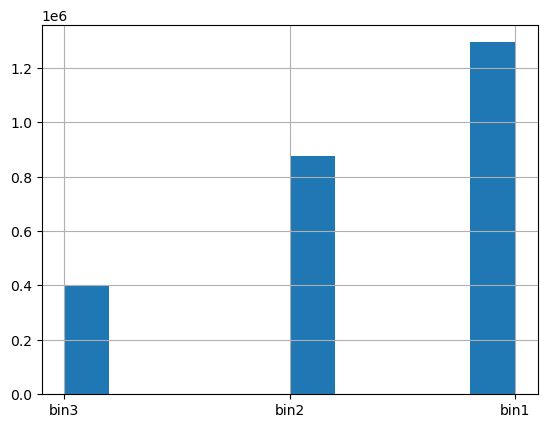

In [19]:
# minute bins
hour_bins = [0, 8, 16, 24]
time_bins = [h*60 for h in hour_bins]
bin_labels = [f"bin{i+1}" for i in range(len(time_bins) - 1)]

vital["time_bin"] = pd.cut(
    vital["observationoffset"],
    bins=time_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)
vital = vital.drop(columns=['observationoffset'])
vital.time_bin.hist()

In [20]:
# average within ID x time_bin, for all K columns
vital_cols = vital.columns.difference(['patienthealthsystemstayid', 'time_from_admit', 'time_bin'])
vital_expanded = vital.groupby(["patienthealthsystemstayid", "time_bin"])[vital_cols].mean().unstack("time_bin")
feature_sets['vitalsaperiodic'] = vital_expanded.columns = [f"{col}_{bin}" for col, bin in vital_expanded.columns]
vital_expanded

,cardiacinput_bin1,cardiacinput_bin2,cardiacinput_bin3,cardiacoutput_bin1,cardiacoutput_bin2,cardiacoutput_bin3,hospitaladmitoffset_bin1,hospitaladmitoffset_bin2,hospitaladmitoffset_bin3,noninvasivediastolic_bin1,noninvasivediastolic_bin2,noninvasivediastolic_bin3,noninvasivemean_bin1,noninvasivemean_bin2,noninvasivemean_bin3,noninvasivesystolic_bin1,noninvasivesystolic_bin2,noninvasivesystolic_bin3,paop_bin1,paop_bin2,paop_bin3,patientunitstayid_bin1,patientunitstayid_bin2,patientunitstayid_bin3,pvr_bin1,pvr_bin2,pvr_bin3,pvri_bin1,pvri_bin2,pvri_bin3,svr_bin1,svr_bin2,svr_bin3,svri_bin1,svri_bin2,svri_bin3
patienthealthsystemstayid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
128927,NaN,NaN,NaN,NaN,NaN,NaN,-22.0,-22.0,-22.0,64.900000,76.250000,73.0,77.600000,93.500000,87.0,102.900000,129.000000,126.0,NaN,NaN,NaN,141179.0,141179.0,141179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128943,NaN,NaN,NaN,NaN,NaN,NaN,-99.0,-99.0,-99.0,72.000000,73.333333,68.0,90.500000,96.000000,96.5,120.500000,131.000000,142.5,NaN,NaN,NaN,141196.0,141196.0,141196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128968,NaN,NaN,NaN,NaN,NaN,NaN,-1004.0,NaN,NaN,64.178571,NaN,NaN,81.107143,NaN,NaN,109.785714,NaN,NaN,NaN,NaN,NaN,141227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128970,NaN,NaN,NaN,NaN,NaN,NaN,-4.0,NaN,NaN,61.818182,NaN,NaN,85.727273,NaN,NaN,124.454545,NaN,NaN,NaN,NaN,NaN,141229.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128995,NaN,NaN,NaN,NaN,NaN,NaN,-18.0,-18.0,NaN,72.222222,76.285714,NaN,83.888889,91.000000,NaN,112.777778,114.857143,NaN,NaN,NaN,NaN,141260.0,141260.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743043,NaN,NaN,NaN,NaN,NaN,NaN,-305.0,-305.0,-305.0,58.375000,53.666667,55.0,76.375000,69.888889,64.0,104.875000,95.555556,83.0,NaN,NaN,NaN,3353184.0,3353184.0,3353184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2743084,NaN,NaN,NaN,NaN,NaN,NaN,-34.0,-34.0,-34.0,92.333333,76.000000,78.0,111.666667,92.000000,92.0,142.777778,120.000000,115.0,NaN,NaN,NaN,3353235.0,3353235.0,3353235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2743086,NaN,NaN,NaN,NaN,NaN,NaN,-14.0,-14.0,-14.0,78.222222,81.111111,76.0,101.555556,105.000000,98.2,136.777778,140.444444,132.0,NaN,NaN,NaN,3353237.0,3353237.0,3353237.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
patient_agg = patient_agg.merge(vital_expanded.reset_index(), on='patienthealthsystemstayid', how='left')
patient_agg

,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,hospitaldischargeyear,mortality_at48h,hospital_numbedscategory,hospital_region,admissionheight,admissionweight,A02.0,A03.9,A04.4,A04.7,A05.9,A09,A15.0,A31.9,A35,A41.9,A48.1,A48.3,A54.42,A81.00,A86,A87.9,B00.2,B00.4,B02.9,B15.9,B17.1,B17.9,B19.10,B20,B25.1,B37.0,B44.1,B49,B54,B59,B69.0,B95.0,B95.6,B96.89,B97.4,C00.2,C06.9,C11.9,C13.9,...,T86.21,T86.40,T86.819,T86.899,T86.90,T88,V08,V42.7,V42.83,V62.84,Y38.6,Z21,Z94.4,Z94.83,cardiacinput_bin1,cardiacinput_bin2,cardiacinput_bin3,cardiacoutput_bin1,cardiacoutput_bin2,cardiacoutput_bin3,hospitaladmitoffset_bin1,hospitaladmitoffset_bin2,hospitaladmitoffset_bin3,noninvasivediastolic_bin1,noninvasivediastolic_bin2,noninvasivediastolic_bin3,noninvasivemean_bin1,noninvasivemean_bin2,noninvasivemean_bin3,noninvasivesystolic_bin1,noninvasivesystolic_bin2,noninvasivesystolic_bin3,paop_bin1,paop_bin2,paop_bin3,patientunitstayid_bin1,patientunitstayid_bin2,patientunitstayid_bin3,pvr_bin1,pvr_bin2,pvr_bin3,pvri_bin1,pvri_bin2,pvri_bin3,svr_bin1,svr_bin2,svr_bin3,svri_bin1,svri_bin2,svri_bin3
0,128927,Female,52,Caucasian,60,2015,0,<100,Midwest,162.6,54.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.0,-22.0,-22.0,64.900000,76.250000,73.0,77.600000,93.500000,87.0,102.900000,129.000000,126.0,NaN,NaN,NaN,141179.0,141179.0,141179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,128943,Male,71,Caucasian,67,2015,0,None,Midwest,162.6,102.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-99.0,-99.0,-99.0,72.000000,73.333333,68.0,90.500000,96.000000,96.5,120.500000,131.000000,142.5,NaN,NaN,NaN,141196.0,141196.0,141196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,128968,Male,82,Caucasian,60,2015,0,<100,Midwest,185.4,82.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,-1004.0,NaN,NaN,64.178571,NaN,NaN,81.107143,NaN,NaN,109.785714,NaN,NaN,NaN,NaN,NaN,141227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,128970,Female,> 89,Caucasian,63,2014,0,100 - 249,Midwest,160.0,89.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,-4.0,NaN,NaN,61.818182,NaN,NaN,85.727273,NaN,NaN,124.454545,NaN,NaN,NaN,NaN,NaN,141229.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128995,Female,43,African American,73,2015,0,>= 500,Midwest,172.7,69.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-18.0,-18.0,NaN,72.222222,76.285714,NaN,83.888889,91.000000,NaN,112.777778,114.857143,NaN,NaN,NaN,NaN,141260.0,141260.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66996,2743043,Female,83,Caucasian,458,2015,0,>= 500,South,163.0,46.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

### Vitals table [periodic]

In [47]:
pd.concat([vital, vital],axis=1)

,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp,patienthealthsystemstayid,time_bin,temperature,sao2,heartrate,respiration,cvp,etco2,systemicsystolic,systemicdiastolic,systemicmean,pasystolic,padiastolic,pamean,st1,st2,st3,icp,patienthealthsystemstayid,time_bin
0,NaN,92.0,88.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.5,-0.5,NaN,128927,bin1,NaN,92.0,88.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.5,-0.5,NaN,128927,bin1
1,NaN,98.0,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.5,-0.4,NaN,128927,bin2,NaN,98.0,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.5,-0.4,NaN,128927,bin2
2,NaN,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,NaN,128927,bin3,NaN,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,NaN,128927,bin3
3,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.1,NaN,128927,bin3,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.1,NaN,128927,bin3
4,NaN,99.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.6,-0.6,NaN,128927,bin1,NaN,99.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.6,-0.6,NaN,128927,bin1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19587090,NaN,99.0,87.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,90.0,10.0,NaN,2743110,bin2,NaN,99.0,87.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,90.0,10.0,NaN,2743110,bin2
19587091,NaN,99.0,81.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,70.0,20.0,NaN,2743110,bin2,NaN,99.0,81.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,70.0,20.0,NaN,2743110,bin2
19587092,NaN,97.0,78.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,60.0,30.0,NaN,2743110,bin2,NaN,97.0,78.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,60.0,30.0,NaN,2743110,bin2
19587093,NaN,99.0,85.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,70.0,20.0,NaN,2743110,bin2,NaN,99.0,85.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,70.0,20.0,NaN,2743110,bin2


In [49]:
vitals = []
for vital_name in ['vitalperiodic', 'vitalaperiodic']:
    vital_ = pd.read_csv(f'{data_dir}/{vital_name}.csv.gz')#.drop(columns=vital_name)
    vital_ = vital_[vital_.patientunitstayid.isin(patient.patientunitstayid.unique())]
    vitals.append(vital_)
vital = pd.concat(vitals,axis=1)
vital = vital.merge(patient[['patientunitstayid','patienthealthsystemstayid', 'hospitaladmitoffset']], on='patientunitstayid', how='left')
vital['time_from_admit'] = - vital.hospitaladmitoffset + vital.observationoffset
vital = vital[vital.time_from_admit <= hours_for_data*60]
vital

ValueError: The column label 'patientunitstayid' is not unique.

<Axes: >

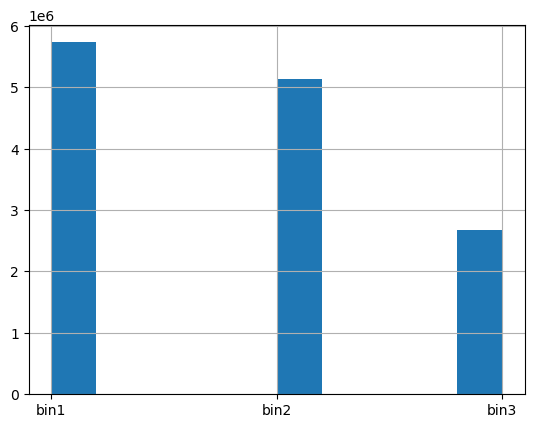

In [37]:
# minute bins
hour_bins = [0, 8, 16, 24]
time_bins = [h*60 for h in hour_bins]
bin_labels = [f"bin{i+1}" for i in range(len(time_bins) - 1)]

vital["time_bin"] = pd.cut(
    vital["observationoffset"],
    bins=time_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)
vital = vital.drop(columns=['observationoffset','hospitaladmitoffset','time_from_admit', 'patientunitstayid'])
vital.time_bin.hist()

In [44]:
# average within ID x time_bin, for all K columns
vital_cols = vital.columns.difference(['patienthealthsystemstayid','time_bin'])
vital_expanded = vital.groupby(["patienthealthsystemstayid", "time_bin"])[vital_cols].mean().unstack("time_bin")
feature_sets['vitals'] = vital_expanded.columns = np.array([f"{col}_{bin}" for col, bin in vital_expanded.columns])
vital_expanded


,cvp_bin1,cvp_bin2,cvp_bin3,etco2_bin1,etco2_bin2,etco2_bin3,heartrate_bin1,heartrate_bin2,heartrate_bin3,icp_bin1,icp_bin2,icp_bin3,padiastolic_bin1,padiastolic_bin2,padiastolic_bin3,pamean_bin1,pamean_bin2,pamean_bin3,pasystolic_bin1,pasystolic_bin2,pasystolic_bin3,respiration_bin1,respiration_bin2,respiration_bin3,sao2_bin1,sao2_bin2,sao2_bin3,st1_bin1,st1_bin2,st1_bin3,st2_bin1,st2_bin2,st2_bin3,st3_bin1,st3_bin2,st3_bin3,systemicdiastolic_bin1,systemicdiastolic_bin2,systemicdiastolic_bin3,systemicmean_bin1,systemicmean_bin2,systemicmean_bin3,systemicsystolic_bin1,systemicsystolic_bin2,systemicsystolic_bin3,temperature_bin1,temperature_bin2,temperature_bin3
patienthealthsystemstayid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
128927,NaN,NaN,NaN,NaN,NaN,NaN,94.562500,96.645833,85.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.597015,99.000000,96.000000,-0.004167,-0.009375,0.000000,-0.385938,-0.178125,0.065217,-0.361979,-0.161458,0.038043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128943,NaN,NaN,NaN,NaN,NaN,NaN,87.064815,74.583333,88.457143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.851852,24.208333,26.779412,95.549020,95.395833,95.700000,-0.346759,-0.200521,-0.275424,-0.970833,-0.691146,-1.362857,-0.608333,-0.456250,-1.033051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128968,NaN,NaN,NaN,NaN,NaN,NaN,102.837209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.337209,NaN,NaN,95.773333,NaN,NaN,-0.098837,NaN,NaN,-0.528488,NaN,NaN,-0.428488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128970,NaN,NaN,NaN,NaN,NaN,NaN,66.225806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.419355,NaN,NaN,95.032258,NaN,NaN,0.451613,NaN,NaN,0.035484,NaN,NaN,-0.412903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128995,NaN,NaN,NaN,NaN,NaN,NaN,74.297619,70.702381,75.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,92.835616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743043,NaN,NaN,NaN,NaN,NaN,NaN,80.494737,83.052083,84.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.768421,22.937500,25.457143,98.673684,97.432099,89.500000,9.368421,5.260417,4.285714,39.842105,9.218750,9.428571,15.157895,8.385417,20.571429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2743084,NaN,NaN,NaN,NaN,NaN,NaN,92.585106,82.229167,84.818182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.808989,32.166667,NaN,95.095745,95.093750,96.090909,24.361702,19.347826,10.454545,23.723404,16.250000,26.818182,45.851064,33.020833,37.272727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2743086,NaN,NaN,NaN,NaN,NaN,NaN,90.610526,89.552083,94.206897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.863158,26.729167,29.689655,94.357895,94.210526,95.793103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
patient_agg = patient_agg.merge(vital_expanded.reset_index(), on='patienthealthsystemstayid', how='left')
patient_agg

,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,hospitaldischargeyear,mortality_at48h,hospital_numbedscategory,hospital_region,admissionheight,admissionweight,A02.0,A03.9,A04.4,A04.7,A05.9,A09,A15.0,A31.9,A35,A41.9,A48.1,A48.3,A54.42,A81.00,A86,A87.9,B00.2,B00.4,B02.9,B15.9,B17.1,B17.9,B19.10,B20,B25.1,B37.0,B44.1,B49,B54,B59,B69.0,B95.0,B95.6,B96.89,B97.4,C00.2,C06.9,C11.9,C13.9,...,etco2_bin2,etco2_bin3,heartrate_bin1,heartrate_bin2,heartrate_bin3,hospitaladmitoffset_bin1_y,hospitaladmitoffset_bin2_y,hospitaladmitoffset_bin3_y,icp_bin1,icp_bin2,icp_bin3,padiastolic_bin1,padiastolic_bin2,padiastolic_bin3,pamean_bin1,pamean_bin2,pamean_bin3,pasystolic_bin1,pasystolic_bin2,pasystolic_bin3,patientunitstayid_bin1_y,patientunitstayid_bin2_y,patientunitstayid_bin3_y,respiration_bin1,respiration_bin2,respiration_bin3,sao2_bin1,sao2_bin2,sao2_bin3,st1_bin1,st1_bin2,st1_bin3,st2_bin1,st2_bin2,st2_bin3,st3_bin1,st3_bin2,st3_bin3,systemicdiastolic_bin1,systemicdiastolic_bin2,systemicdiastolic_bin3,systemicmean_bin1,systemicmean_bin2,systemicmean_bin3,systemicsystolic_bin1,systemicsystolic_bin2,systemicsystolic_bin3,temperature_bin1,temperature_bin2,temperature_bin3
0,128927,Female,52,Caucasian,60,2015,0,<100,Midwest,162.6,54.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,94.562500,96.645833,85.750000,-21.916667,-22.0,-22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.411790e+05,141179.0,141179.0,NaN,NaN,NaN,98.597015,99.000000,96.000000,-0.004167,-0.009375,0.000000,-0.385938,-0.178125,0.065217,-0.361979,-0.161458,0.038043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,128943,Male,71,Caucasian,67,2015,0,None,Midwest,162.6,102.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,87.064815,74.583333,88.457143,-89.495413,-99.0,-99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.411961e+05,141196.0,141196.0,21.851852,24.208333,26.779412,95.549020,95.395833,95.700000,-0.346759,-0.200521,-0.275424,-0.970833,-0.691146,-1.362857,-0.608333,-0.456250,-1.033051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,128968,Male,82,Caucasian,60,2015,0,<100,Midwest,185.4,82.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,102.837209,NaN,NaN,-1004.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.412270e+05,NaN,NaN,31.337209,NaN,NaN,95.773333,NaN,NaN,-0.098837,NaN,NaN,-0.528488,NaN,NaN,-0.428488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,128970,Female,> 89,Caucasian,63,2014,0,100 - 249,Midwest,160.0,89.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,66.225806,NaN,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.412290e+05,NaN,NaN,21.419355,NaN,NaN,95.032258,NaN,NaN,0.451613,NaN,NaN,0.035484,NaN,NaN,-0.412903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128995,Female,43,African American,73,2015,0,>= 500,Midwest,172.7,69.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,74.297619,70.702381,75.142857,-18.000000,-18.0,-18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.412600e+05,141260.0,141260.0,NaN,NaN,NaN,98.000000,92.835616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

### Lab table

In [26]:
lab = pd.read_csv(f'{data_dir}/lab.csv.gz')
lab = lab[lab.patientunitstayid.isin(patient.patientunitstayid.unique())]
lab["labname"] = lab["labname"].str.lower().replace("-",'').replace(' ', '')
lab = lab.merge(patient[['patientunitstayid', 'hospitaladmitoffset']], on='patientunitstayid', how='left')
lab['time_from_admit'] = - lab.hospitaladmitoffset + lab.labresultoffset
lab = lab[lab.time_from_admit <= hours_for_data*60]
lab

,labid,patientunitstayid,labresultoffset,labtypeid,labname,labresult,labresulttext,labmeasurenamesystem,labmeasurenameinterface,labresultrevisedoffset,hospitaladmitoffset,time_from_admit
0,49716893,141178,-280,2,salicylate,2.3,2.3,mg/dL,mg/dL,-212,-14,-266
1,53200537,141178,-280,3,RDW,11.9,11.9,%,%,-216,-14,-266
2,48867931,141178,-280,1,total protein,7.4,7.4,g/dL,g/dL,-212,-14,-266
3,53200534,141178,-280,3,MCV,94.8,94.8,fL,fl,-216,-14,-266
4,49716894,141178,-280,2,Acetaminophen,NaN,<2,mcg/mL,mcg/mL,-212,-14,-266
...,...,...,...,...,...,...,...,...,...,...,...,...
8029545,826336611,3353263,-37,3,PTT,25.0,25,sec,sec,54,-108,71
8029547,824772677,3353263,-7,3,MCH,27.0,27,pg,pg,6,-108,101
8029549,824772676,3353263,-7,3,RDW,13.3,13.3,%,%,6,-108,101
8029551,824772675,3353263,-7,3,WBC x 1000,6.4,6.4,K/mcL,K/uL,6,-108,101


In [27]:
lab.groupby(lab.labname).labmeasurenameinterface.value_counts()[:40]

labname                   labmeasurenameinterface
24 h urine protein        mg/dL                        475
                          mg/24HR                        3
                          mg/24Hr                        2
                          g/24Hr                         2
                          mg/24 hr                       1
                          mg/24 hrs                      1
                          g/24 hours                     1
                          MG/24HR                        1
24 h urine urea nitrogen  mg/dL                         49
                          g/24h                          1
                          g/24 hr                        1
ALT (SGPT)                U/L                        34198
                          IU/L                       20786
                          Units/L                     4858
                          unit/L                       819
                          u/L                          338
      

In [28]:
lab_expanded = (
    lab.groupby(["patientunitstayid", "labname"])["labresult"]
        .mean()
        .unstack()
        .reset_index()
)

lab_expanded

labname,patientunitstayid,24 h urine protein,24 h urine urea nitrogen,ALT (SGPT),ANF/ANA,AST (SGOT),Acetaminophen,Amikacin peak,Amikacin random,BNP,BUN,Base Deficit,Base Excess,CPK,CPKMB,CPKMB INDEX,CRP,CRPhs,Carbamazepine,Carboxyhemoglobin,Clostridium difficile toxin A+B,Cyclosporin,Device,Digoxin,ESR,Fe,Fe/TIBC Ratio,Ferritin,FiO2,Gentamicin peak,Gentamicin random,Gentamicin trough,HCO3,HDL,HIV 1&2 AB,HSV 1&2 IgG AB,Hct,Hgb,LDH,LDL,LPM O2,Legionella pneumophila Ab,Lidocaine,Lithium,MCH,MCHC,MCV,MPV,Methemoglobin,Mode,...,calcium,cd 4,chloride,cortisol,creatinine,direct bilirubin,eos,ethanol,fibrinogen,folate,free T4,glucose,glucose CSF,haptoglobin,ionized calcium,lactate,lipase,lymphs,magnesium,monos,myoglobin,pH,paCO2,paO2,phosphate,platelets x 1000,polys,potassium,prealbumin,prolactin,protein CSF,protein C,protein S,reticulocyte count,salicylate,serum ketones,serum osmolality,sodium,total bilirubin,total cholesterol,total protein,transferrin,triglycerides,troponin I,troponin T,uric acid,urinary creatinine,urinary osmolality,urinary sodium,urinary specific gravity
0,141178,NaN,NaN,52.0,NaN,40.0,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.6,15.500000,NaN,NaN,NaN,NaN,NaN,NaN,33.7,35.600000,94.8,NaN,NaN,NaN,...,8.0,NaN,108.0,NaN,0.700000,NaN,3.0,234.0,NaN,NaN,NaN,77.000000,NaN,NaN,NaN,NaN,NaN,45.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,273.0,45.0,3.600,NaN,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,146.0,0.4,NaN,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,141179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.2,NaN,107.5,NaN,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,141196,NaN,NaN,18.0,NaN,15.0,NaN,NaN,NaN,NaN,16.000000,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,31.7,10.300000,NaN,NaN,3.0,NaN,NaN,NaN,28.1,32.500000,86.4,NaN,NaN,NaN,...,9.0,NaN,97.0,NaN,0.800000,NaN,0.0,NaN,NaN,NaN,NaN,144.000000,NaN,NaN,NaN,0.80,NaN,3.0,NaN,2.0,NaN,7.43,45.0,70.0,NaN,453.0,95.0,4.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.0,0.3,NaN,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,141197,NaN,NaN,19.0,NaN,17.0,NaN,NaN,NaN,24.0,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.4,11.500000,NaN,NaN,NaN,NaN,NaN,NaN,27.2,31.600000,86.1,NaN,NaN,NaN,...,9.0,NaN,99.0,NaN,0.930000,NaN,0.0,NaN,NaN,NaN,NaN,162.000000,NaN,NaN,NaN,NaN,NaN,3.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,589.0,90.0,4.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139.0,0.3,NaN,8.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,141227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,726.0,27.666667,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,11.0,NaN,NaN,NaN,27.3,8.333333,NaN,NaN,NaN,NaN,NaN,NaN,26.8,30.533333,87.7,NaN,NaN,NaN,...,8.5,NaN,102.0,NaN,1.433333,NaN,1.5,NaN,NaN,NaN,NaN,132.333333,NaN,NaN,NaN,2.85,NaN,10.0,2.05,2.5,NaN,7.37,20.0,64.0,NaN,235.0,52.0,4.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.0,NaN,NaN,NaN,NaN,NaN,0.325000,NaN,NaN,NaN,NaN,NaN,1.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68904,3353184,NaN,NaN,11.0,NaN,30.0,NaN,NaN,NaN,592.5,26.000000,NaN,NaN,104.0,17.10,16.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0,NaN,NaN,32.5,11.200000,NaN,62.0,NaN,NaN,NaN,NaN,35.0,34.500000,100.5,8.55,NaN,Na

In [29]:
lab_cols = lab_expanded.columns.difference(['patientunitstayid'])
feature_sets['labs'] = lab_cols
lab_expanded_agg = patient[['patientunitstayid', 'patienthealthsystemstayid']].merge(lab_expanded, on='patientunitstayid', how='left'
              ).groupby('patienthealthsystemstayid')[lab_cols].mean().reset_index()
patient_agg= patient_agg.merge(lab_expanded_agg, on= 'patienthealthsystemstayid', how='left')
patient_agg

,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,hospitaldischargeyear,mortality_at48h,hospital_numbedscategory,hospital_region,admissionheight,admissionweight,A02.0,A03.9,A04.4,A04.7,A05.9,A09,A15.0,A31.9,A35,A41.9,A48.1,A48.3,A54.42,A81.00,A86,A87.9,B00.2,B00.4,B02.9,B15.9,B17.1,B17.9,B19.10,B20,B25.1,B37.0,B44.1,B49,B54,B59,B69.0,B95.0,B95.6,B96.89,B97.4,C00.2,C06.9,C11.9,C13.9,...,calcium,cd 4,chloride,cortisol,creatinine,direct bilirubin,eos,ethanol,fibrinogen,folate,free T4,glucose,glucose CSF,haptoglobin,ionized calcium,lactate,lipase,lymphs,magnesium,monos,myoglobin,pH,paCO2,paO2,phosphate,platelets x 1000,polys,potassium,prealbumin,prolactin,protein CSF,protein C,protein S,reticulocyte count,salicylate,serum ketones,serum osmolality,sodium,total bilirubin,total cholesterol,total protein,transferrin,triglycerides,troponin I,troponin T,uric acid,urinary creatinine,urinary osmolality,urinary sodium,urinary specific gravity
0,128927,Female,52,Caucasian,60,2015,0,<100,Midwest,162.6,54.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.10,NaN,107.75,NaN,0.700000,NaN,3.0,234.0,NaN,NaN,NaN,74.500000,NaN,NaN,NaN,NaN,NaN,45.0,1.90,7.0,NaN,NaN,NaN,NaN,NaN,273.0,45.0,3.750,NaN,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,144.5,0.4,NaN,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,128943,Male,71,Caucasian,67,2015,0,None,Midwest,162.6,102.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.00,NaN,98.00,NaN,0.865000,NaN,0.0,NaN,NaN,NaN,NaN,153.000000,NaN,NaN,NaN,0.80,NaN,3.0,NaN,4.5,NaN,7.43,45.0,70.0,NaN,521.0,92.5,4.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137.0,0.3,NaN,7.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,128968,Male,82,Caucasian,60,2015,0,<100,Midwest,185.4,82.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.50,NaN,102.00,NaN,1.433333,NaN,1.5,NaN,NaN,NaN,NaN,132.333333,NaN,NaN,NaN,2.85,NaN,10.0,2.05,2.5,NaN,7.37,20.0,64.0,NaN,235.0,52.0,4.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.0,NaN,NaN,NaN,NaN,NaN,0.325000,NaN,NaN,NaN,NaN,NaN,1.025
3,128970,Female,> 89,Caucasian,63,2014,0,100 - 249,Midwest,160.0,89.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.45,NaN,101.50,NaN,1.245000,NaN,1.0,NaN,NaN,NaN,NaN,193.500000,NaN,NaN,NaN,NaN,NaN,29.0,2.20,8.0,NaN,7.36,52.0,71.0,NaN,281.0,61.5,3.450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.5,0.3,259.0,7.8,NaN,77.0,NaN,NaN,NaN,NaN,NaN,NaN,1.015
4,128995,Female,43,African American,73,2015,0,>= 500,Midwest,172.7,69.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.95,NaN,103.50,NaN,1.075000,NaN,1.0,NaN,NaN,NaN,NaN,191.500000,NaN,NaN,NaN,NaN,NaN,47.0,1.90,7.0,NaN,NaN,NaN,NaN,NaN,234.5,45.0,4.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.0,0.3,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66996,2743043,Female,83,Caucasian,458,2015,0,>= 500,South,163.0,46.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.10,NaN,100.00,NaN,0.705000,0.1,0.0,NaN,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,NaN,NaN,8.0,1.70,3.0,NaN,NaN,NaN,NaN,NaN,135.0,NaN,3.650,NaN

In [31]:
feature_sets

{'icd10_before24h': Index(['A02.0', 'A03.9', 'A04.4', 'A04.7', 'A05.9', 'A09', 'A15.0', 'A31.9',
        'A35', 'A41.9',
        ...
        'T86.90', 'T88', 'V08', 'V42.7', 'V42.83', 'V62.84', 'Y38.6', 'Z21',
        'Z94.4', 'Z94.83'],
       dtype='object', length=729),
 'vitalsaperiodic': ['cardiacinput_bin1',
  'cardiacinput_bin2',
  'cardiacinput_bin3',
  'cardiacoutput_bin1',
  'cardiacoutput_bin2',
  'cardiacoutput_bin3',
  'hospitaladmitoffset_bin1',
  'hospitaladmitoffset_bin2',
  'hospitaladmitoffset_bin3',
  'noninvasivediastolic_bin1',
  'noninvasivediastolic_bin2',
  'noninvasivediastolic_bin3',
  'noninvasivemean_bin1',
  'noninvasivemean_bin2',
  'noninvasivemean_bin3',
  'noninvasivesystolic_bin1',
  'noninvasivesystolic_bin2',
  'noninvasivesystolic_bin3',
  'paop_bin1',
  'paop_bin2',
  'paop_bin3',
  'patientunitstayid_bin1',
  'patientunitstayid_bin2',
  'patientunitstayid_bin3',
  'pvr_bin1',
  'pvr_bin2',
  'pvr_bin3',
  'pvri_bin1',
  'pvri_bin2',
  'pvri_bin3',

### Analyze data 

In [32]:
num_cols = feature_sets['labs'].tolist() + feature_sets['vitals'].tolist() + ['age', 'admissionheight', 'admissionweight']
bin_cols = feature_sets['icd10_before24h'].tolist()
cat_cols = ['hospital_region', 'ethnicity', 'gender', 'hospital_numbedscategory', 'hospital_dischargeyear']

data = patient_agg.copy()
data.loc[data.age == '> 89', 'age'] = 90


In [ ]:
data.isna().mean().sort_values(ascending=False)

In [ ]:
np.setdiff1d(data.columns, num_cols+bin_cols+cat_cols)

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=True), cat_cols),
        ("bin", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True), bin_cols),
    ]
)
data_pp = preprocess(data[num_cols + cat_cols + bin_cols])
data_pp

In [33]:
data[num_cols].isna().mean()

KeyError: "['hospitaladmitoffset_bin1', 'hospitaladmitoffset_bin2', 'hospitaladmitoffset_bin3', 'patientunitstayid_bin1', 'patientunitstayid_bin2', 'patientunitstayid_bin3'] not in index"

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


X = data[num_cols + cat_cols]
y = data['mortality_at48h']
print(X.shape)
# --- preprocessing ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=True), cat_cols),
        ("bin", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True), bin_cols),
    ]
)

# --- model ---
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

# --- CV ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring={
        "auroc": "roc_auc",
        "auprc": "average_precision"
    },
    return_train_score=False
)

print("AUROC:", scores["test_auroc"].mean())
print("AUPRC:", scores["test_auprc"].mean())

# --- optional holdout ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score, average_precision_score

y_proba = pipe.predict_proba(X_test)[:, 1]

print("Test AUROC:", roc_auc_score(y_test, y_proba))
print("Test AUPRC:", average_precision_score(y_test, y_proba))

(67001, 185)


/Users/kara/anaconda3/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/kara/anaconda3/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/kara/anaconda3/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


AUROC: 0.6805450365572853
AUPRC: 0.07903468781460697


/Users/kara/anaconda3/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Test AUROC: 0.6863831994349785
Test AUPRC: 0.07177055300443354


In [ ]:
for p in os.listdir('./eicu-collaborative-research-database-demo-2.0.1/'):
    if not p.endswith('.csv.gz'):
        print(p)
        continue
    data_dir = './eicu-collaborative-research-database-demo-2.0.1/'
    df = pd.read_csv(f'{data_dir}/{p}')
    print(p)
    display(df.head())

diagnosis.csv.gz


,diagnosisid,patientunitstayid,activeupondischarge,diagnosisoffset,diagnosisstring,icd9code,diagnosispriority
0,7607199,346380,False,5028,cardiovascular|ventricular disorders|hypertension,"401.9, I10",Other
1,7570429,346380,False,685,neurologic|altered mental status / pain|change...,"780.09, R41.82",Major
2,7705483,346380,True,5035,cardiovascular|shock / hypotension|hypotension,"458.9, I95.9",Major
3,7848601,346380,True,5035,neurologic|altered mental status / pain|schizo...,"295.90, F20.9",Major
4,7451475,346380,False,5028,pulmonary|disorders of vasculature|pulmonary e...,"415.19, I26.99",Major


vitalAperiodic.csv.gz


,vitalaperiodicid,patientunitstayid,observationoffset,noninvasivesystolic,noninvasivediastolic,noninvasivemean,paop,cardiacoutput,cardiacinput,svr,svri,pvr,pvri
0,3661418,141764,81,171.0,90.0,116.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3661424,141764,334,153.0,78.0,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3661417,141764,77,176.0,87.0,107.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3661419,141764,165,173.0,106.0,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3661421,141764,255,182.0,103.0,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


admissionDx.csv.gz


...

medication.csv.gz


/var/folders/gv/cvbvg4412fg914zd3_cc80lh0000gn/T/ipykernel_22833/313154529.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{data_dir}/{p}')


,medicationid,patientunitstayid,drugorderoffset,drugstartoffset,drugivadmixture,drugordercancelled,drugname,drughiclseqno,dosage,routeadmin,frequency,loadingdose,prn,drugstopoffset,gtc
0,7278819,141765,134,1396,No,No,WARFARIN SODIUM 5 MG PO TABS,2812.0,5 3,PO,NaN,NaN,No,2739,0
1,9726266,141765,1,-188,No,No,5 ML VIAL : DILTIAZEM HCL 25 MG/5ML IV SOLN,182.0,15 3,IV,Once PRN,NaN,Yes,171,38
2,10293599,141765,115,856,No,No,ASPIRIN EC 81 MG PO TBEC,1820.0,81 3,PO,Daily,NaN,No,2739,0
3,10871534,141765,114,316,No,No,DILTIAZEM HCL 30 MG PO TABS,182.0,30 3,PO,Q6H SCH,NaN,No,2739,0
4,10128716,141765,115,856,No,No,LISINOPRIL 5 MG PO TABS,132.0,5 3,PO,Daily,NaN,No,2428,0


intakeOutput.csv.gz


,intakeoutputid,patientunitstayid,intakeoutputoffset,intaketotal,outputtotal,dialysistotal,nettotal,intakeoutputentryoffset,cellpath,celllabel,cellvaluenumeric,cellvaluetext
0,9314532,147307,-394,0.0,0.0,0.0,0.0,-394,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bod...,Bodyweight (lb),159.8,159.8
1,9314533,147307,-394,0.0,0.0,0.0,0.0,-394,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bod...,Bodyweight (kg),72.5,72.5
2,9319306,211715,1533,120.0,0.0,0.0,120.0,1533,flowsheet|Flowsheet Cell Labels|I&O|Intake (ml...,P.O.,120.0,120.0
3,9319891,219981,6504,120.0,0.0,0.0,120.0,6504,flowsheet|Flowsheet Cell Labels|I&O|Intake (ml...,P.O.,120.0,120.0
4,9319987,158057,624,0.0,0.0,0.0,0.0,624,flowsheet|Flowsheet Cell Labels|I&O|Weight|Bod...,Bodyweight (lb),359.0,359.0


In [ ]:
patient.hospitalid.value_counts(dropna=False)

hospitalid
146    40
123    30
171    25
157    25
167    24
       ..
408    10
384    10
383    10
397    10
259    10
Name: count, Length: 186, dtype: int64

In [ ]:
patient.ethnicity.value_counts(dropna=False)

ethnicity
Caucasian           2010
African American     231
Hispanic             115
Other/Unknown         83
NaN                   39
Asian                 30
Native American       12
Name: count, dtype: int64

In [ ]:
# Create a database connection using settings from config file
config='../db/config.ini'

# connection info
conn_info = dict()
if os.path.isfile(config):
    config = ConfigObj(config)
    conn_info["sqluser"] = config['username']
    conn_info["sqlpass"] = config['password']
    conn_info["sqlhost"] = config['host']
    conn_info["sqlport"] = config['port']
    conn_info["dbname"] = config['dbname']
    conn_info["schema_name"] = config['schema_name']
else:
    conn_info["sqluser"] = 'postgres'
    conn_info["sqlpass"] = ''
    conn_info["sqlhost"] = 'localhost'
    conn_info["sqlport"] = 5432
    conn_info["dbname"] = 'eicu'
    conn_info["schema_name"] = 'public,eicu_crd'
    
# Connect to the eICU database
print('Database: {}'.format(conn_info['dbname']))
print('Username: {}'.format(conn_info["sqluser"]))
if conn_info["sqlpass"] == '':
    # try connecting without password, i.e. peer or OS authentication
    try:
        if (conn_info["sqlhost"] == 'localhost') & (conn_info["sqlport"]=='5432'):
            con = psycopg2.connect(dbname=conn_info["dbname"],
                                   user=conn_info["sqluser"])            
        else:
            con = psycopg2.connect(dbname=conn_info["dbname"],
                                   host=conn_info["sqlhost"],
                                   port=conn_info["sqlport"],
                                   user=conn_info["sqluser"])
    except:
        conn_info["sqlpass"] = getpass.getpass('Password: ')

        con = psycopg2.connect(dbname=conn_info["dbname"],
                               host=conn_info["sqlhost"],
                               port=conn_info["sqlport"],
                               user=conn_info["sqluser"],
                               password=conn_info["sqlpass"])
query_schema = 'set search_path to ' + conn_info['schema_name'] + ';'

Database: eicu
Username: postgres


NameError: name 'getpass' is not defined

In [ ]:
conda create --name cs197-rag python=3.12
